In [1]:
import sys
sys.path.append("..")

import pickle
from itertools import product
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import torch
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import shap
from mlresearch.datasets import BinaryDatasets, ContinuousCategoricalDatasets
from tabpfn import TabPFNRegressor
from explainerpfn.base import ExplainerPFN
from explainerpfn.train import SyntheticDataGenerator
from explainerpfn.train._activations import identity

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
    # Total and free memory in bytes
    free, total = torch.cuda.mem_get_info()
    print(f"Total memory: {total / 1024**2:.2f}MB")
    print(f"Free memory: {free / 1024**2:.2f}MB")
else:
    print("No GPU available. Training will run on CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random_state = 42
max_samples = 20000
max_features = 15
model_path = "../../explainerpfn_model_NOV_15.ckp"

No GPU available. Training will run on CPU.


# Collect datasets

In [2]:
datasets = BinaryDatasets().download()
datasets.content_ += ContinuousCategoricalDatasets().download().content_
content_processed = []
for name, df in datasets:
    df.columns = df.columns.astype(str)
    df = df.loc[:, ~df.columns.str.startswith("cat")].copy()
    if df.target.nunique() > 2:
        df.target = (df.target == df.target.mode().iloc[0]).astype(int)
    
    if df.shape[1] < max_features and df.shape[1] > 2 and df.shape[0] < max_samples:
        content_processed.append((name, df))

datasets.content_ = content_processed
datasets.summarize_datasets()

Datasets:   0%|          | 0/7 [00:00<?, ?it/s]

Datasets:   0%|          | 0/16 [00:00<?, ?it/s]

,Features,Observations,Minority Obs.,Majority Obs.,Imbalance Ratio,Classes
Dataset name,,,,,,
HEART DISEASE,5,740,357,383,1.07,2
CREDIT APPROVAL,6,653,296,357,1.21,2
HEART,6,270,120,150,1.25,2
BANKNOTE AUTHENTICATION,4,1372,610,762,1.25,2
CONTRACEPTIVE,5,1473,629,844,1.34,2
FLAGS,10,194,60,134,2.23,2
GERMAN CREDIT,7,1000,300,700,2.33,2
THYROID,6,5789,1621,4168,2.57,2
ECHOCARDIOGRAM,8,61,17,44,2.59,2


# Collect explanations

In [3]:
def few_shot_explanations(X_train, y_train, explanations_train, X_test, y_test, model, n_samples=5, random_state=42):

    X_train_sample, _, y_train_sample, _, explanations_sample, _ = train_test_split(
        X_train, y_train, explanations_train,
        train_size=n_samples, 
        random_state=random_state
    )
    Xy_sample = np.concatenate([X_train_sample, y_train_sample.reshape(-1, 1)], axis=1)
    Xy_test = np.concatenate([X_test, y_test.reshape(-1, 1)], axis=1) 

    tabpfn_preds = np.zeros(X_test.shape, dtype=float)
    for i in range(X_test.shape[1] - 1): 
        exp_target = explanations_sample[:, i]

        model.fit(Xy_sample, exp_target)

        pred = model.predict(Xy_test)
        tabpfn_preds[:, i] = pred

    return tabpfn_preds


In [4]:
def run_experiments_across_datasets(datasets, model_path, base_model, few_shot_sample_size, few_shot_predictors, random_state=42):
    results = {}

    for dataset_name, df in tqdm(datasets):

        results[dataset_name] = {}
        X = df.drop(columns=["target"]).values
        y = df["target"].values

        # Train a model and get predictions
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)
        model = clone(base_model)
        model.fit(X_train, y_train)
        y_train_scores = model.predict_proba(X_train)[:, 1]
        y_test_scores = model.predict_proba(X_test)[:, 1]
        results[dataset_name]["X_train"] = X_train
        results[dataset_name]["X_test"] = X_test
        results[dataset_name]["y_train"] = y_train
        results[dataset_name]["y_test"] = y_test
        results[dataset_name]["model"] = model
        results[dataset_name]["y_train_scores"] = y_train_scores
        results[dataset_name]["y_test_scores"] = y_test_scores

        shap_explanations = shap.Explainer(model.named_steps["mlp"].predict_proba, model.named_steps["scaler"].transform(X_train))
        shap_values_train = shap_explanations(model.named_steps["scaler"].transform(X_train)).values[:, :, -1]
        shap_values_test = shap_explanations(model.named_steps["scaler"].transform(X_test)).values[:, :, -1]
        results[dataset_name]["shap"] = shap_values_test

        xai = ExplainerPFN(model_path=model_path, random_state=random_state, device=device)
        xai.fit(np.concatenate([X_train, X_test], axis=0), np.concatenate([y_train_scores, y_test_scores], axis=0))
        exp_pfn_values = xai.predict(X_test, y_test_scores)
        results[dataset_name]["explainerpfn"] = exp_pfn_values / np.sqrt(X.shape[1])  # Normalize by number of features

        results[dataset_name]["explainerpfn_statistical+additive"] = xai.apply_correction(y_test_scores, exp_pfn_values, kind=["statistical", "additive"])
        results[dataset_name]["explainerpfn_statistical+multiplicative"] = xai.apply_correction(y_test_scores, exp_pfn_values, kind=["statistical", "multiplicative"])

        for n_samples, (model_name, model) in product(few_shot_sample_size, few_shot_predictors.items()):
            model = clone(model)
            exp_few_shot = few_shot_explanations(X_train, y_train, shap_values_train, X_test, y_test, model, n_samples=n_samples, random_state=random_state)
            results[dataset_name][f"{model_name}_n{n_samples}"] = exp_few_shot
        
        return results

In [ ]:
# Structured as Dict[dataset_name, Dict[model_name, explanations]]
base_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(hidden_layer_sizes=(12, 12), max_iter=5000, random_state=random_state))
    ]
)
few_shot_sample_size = [2, 4, 6, 8, 10]
few_shot_predictors = {
    "tabpfn": TabPFNRegressor(model_path="tabpfn-v2-regressor.ckpt", random_state=random_state, device=device),
    "mlp": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(hidden_layer_sizes=(12, 12), max_iter=5000, random_state=random_state))
        ]
    ),
    "rfr": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("rfr", RandomForestRegressor(n_estimators=500, random_state=random_state))
        ]
    )
}


# Get results across datasets
results = run_experiments_across_datasets(
    datasets=datasets,
    model_path=model_path,
    base_model=base_model,
    few_shot_sample_size=few_shot_sample_size,
    few_shot_predictors=few_shot_predictors,
    random_state=random_state
)

# Save results
with open("results_across_datasets_mlp.pkl", "wb") as f:
    pickle.dump(results, f)

  0%|          | 0/12 [00:00<?, ?it/s]

/var/home/joaofonseca/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/var/home/joaofonseca/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/var/home/joaofonseca/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/var/home/joaofonseca/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
ExactExplainer explainer: 2924it [00:15, 57.94it/s]                           
/var/home/joaofonseca/min

# Getting new results

In [3]:
with open("results_across_datasets.pkl", "rb") as f:
    results = pickle.load(f)


In [7]:
model_path = "../../explainerpfn_model_NOV_15.ckp"

# Compute results for new explainerpfn model individually
for dataset_name, df in tqdm(datasets):
    X_train = results[dataset_name]["X_train"]
    X_test = results[dataset_name]["X_test"]
    y_train_scores = results[dataset_name]["y_train_scores"]
    y_test_scores = results[dataset_name]["y_test_scores"]

    model_name = model_path.split("/")[-1].replace(".ckp", "")
    xai = ExplainerPFN(model_path=model_path, random_state=random_state)
    xai.fit(np.concatenate([X_train, X_test], axis=0), np.concatenate([y_train_scores, y_test_scores], axis=0))
    exp_pfn_values = xai.predict(X_test, y_test_scores)
    results[dataset_name][model_name] = exp_pfn_values / np.sqrt(X_test.shape[1])  # Normalize by number of features
    
    results[dataset_name][f"{model_name}_statistical+additive"] = xai.apply_correction(y_test_scores, exp_pfn_values, kind=["statistical", "additive"])

  0%|          | 0/12 [00:00<?, ?it/s]

# Results Analysis

In [4]:
def top_k_jaccard_similarity(arr1, arr2, k=3):
    if arr1.ndim == 1:
        arr1 = arr1.reshape(1, -1)
    if arr2.ndim == 1:
        arr2 = arr2.reshape(1, -1)

    feats1 = np.argpartition(arr1, -k, axis=1)[:, -k:]
    feats2 = np.argpartition(arr2, -k, axis=1)[:, -k:]

    intersection = [np.intersect1d(row1, row2).shape[0] for row1, row2 in zip(feats1, feats2)]
    union = [row1.shape[0] + row2.shape[0] - intersect for row1, row2, intersect in zip(feats1, feats2, intersection)]
    return np.array(intersection) / np.array(union)


def get_results_tables(
    results_dict,
    jaccard_perc=1/3
):
    model_names = [
        key for key in list(results_dict.values())[0]
        if not (key.startswith("X_") or key.startswith("y_") or key == "model")
    ]

    # Compute metrics
    mse = {}
    corr = {}
    jaccard = {}
    for dataset_name in results_dict:
        mse[dataset_name] = {}
        corr[dataset_name] = {}
        jaccard[dataset_name] = {}
        jaccard_k = max(1, int(results_dict[dataset_name]["X_test"].shape[1] * jaccard_perc))
        shap_values_test = results_dict[dataset_name]["shap"]
        for model_name in model_names:
            exp_values = results_dict[dataset_name][model_name]
            mse[dataset_name][model_name] = np.mean((exp_values - shap_values_test) ** 2)
            corr[dataset_name][model_name] = np.corrcoef(exp_values.ravel(), shap_values_test.ravel())[0, 1]
            jaccard[dataset_name][model_name] = np.mean(top_k_jaccard_similarity(exp_values, shap_values_test, k=jaccard_k))

    dataframes = []
    for metric in [mse, corr, jaccard]:
        df_metric = pd.DataFrame(metric).drop(["explainerpfn_statistical+multiplicative", "explainerpfn"])
        df_metric["Method"] = df_metric.index.map(lambda x: "_".join(x.split("_")[:-1]))
        df_metric["Samples"] = df_metric.index.map(lambda x: x.split("_n")[-1]).map(lambda x: int(x) if x.isdigit() else 0)
        df_metric = df_metric[df_metric["Method"] != "shap"]
        df_metric = df_metric.set_index(["Method", "Samples"]).sort_index()
        dataframes.append(df_metric.copy())
    
    df_mse, df_corr, df_jaccard = dataframes
    return df_mse, df_corr, df_jaccard

In [5]:
df_mse, df_corr, df_jaccard = get_results_tables(results)

In [6]:
df_mse

BANKNOTE AUTHENTICATION   ABALONE     ANNEALING  \
Method       Samples                                                    
             0                       0.000000  0.000000  0.000000e+00   
explainerpfn 0                       0.027516  0.003714  1.345341e-02   
mlp          2                      83.433686  0.476673  1.859961e+06   
             4                       0.828345  0.160801  1.343024e+03   
             6                       0.537626  0.028267  1.092150e+03   
             8                       0.062687  0.024987  1.000348e+03   
             10                      0.033595  0.028850  9.120971e+02   
tabpfn       2                       0.066630  0.006352  9.417605e-03   
             4                       0.025548  0.006340  1.035940e-02   
             6                       0.040329  0.002157  9.463919e-03   
             8                       0.009797  0.002331  8.680006e-03   
             10                      0.005205  0.002080  8.562132e-03   

                      CONTRACEPTIVE  CREDIT APPROVAL  ECHOCARDIOGRAM  \
Method       Samples                                                   
             0             0.000000         0.000000        0.000000   
explainerpfn 0             0.018855         0.020080        0.021122   
mlp          2             0.339561    746455.618974        6.930000   
             4             0.228189        32.756474        0.081307   
             6             0.166590        12.705326        0.055668   
             8             0.121720        65.148445        0.052629   
             10            0.133458        98.375309        0.033237   
tabpfn       2             0.023438         0.021397        0.020092   
             4             0.008579         0.013095        0.007161   
             6             0.012853         0.007643        0.003337   
             8             0.011777         0.006266        0.003081   
             10            0.005911         0.005395        0.002668   

                         FLAGS  GERMAN CREDIT     HEART  HEART DISEASE  \
Method       Samples                                                     
             0        0.000000       0.000000  0.000000       0.000000   
explainerpfn 0        0.021532       0.016064  0.024168       0.017237   
mlp          2        1.436895       5.922653  0.939280       0.480335   
             4        0.082788       1.065797  0.278450     105.233817   
             6        0.063573       0.195585  0.313143       0.641703   
             8        0.066631       0.192473  0.267201       0.218060   
             10       0.111186       0.125341  0.227436       0.239260   
tabpfn       2        0.013669       0.008268  0.023848       0.017060   
             4        0.008695       0.005788  0.019771       0.014515   
             6        0.007662       0.007101  0.015782       0.013923   
             8        0.007839       0.005956  0.014350       0.012516   
             10       0.007341       0.005566  0.013404       0.033900   

                      HEPATITIS        THYROID  
Method       Samples                            
             0         0.000000       0.000000  
explainerpfn 0         0.015455       0.036756  
mlp          2         0.165117  205100.854910  
             4         0.199174     408.174587  
             6         0.374827     445.832215  
             8         0.508113     213.834240  
             10        0.672762     356.284271  
tabpfn       2         0.020285       0.024928  
             4         0.020872       0.037746  
             6         0.020475       0.031833  
             8         0.019978       0.027298  
             10        0.019925       0.010609

In [7]:
df_corr

BANKNOTE AUTHENTICATION   ABALONE  ANNEALING  \
Method       Samples                                                 
             0                       1.000000  1.000000   1.000000   
explainerpfn 0                       0.711399  0.196752   0.366921   
mlp          2                      -0.054161 -0.005539  -0.045698   
             4                       0.023947  0.220634   0.160985   
             6                       0.083452  0.153746   0.159405   
             8                       0.743051  0.180081   0.158605   
             10                      0.733919  0.143403   0.159554   
tabpfn       2                       0.066474  0.020104   0.031936   
             4                       0.716766  0.143421   0.018705   
             6                       0.837231  0.585365   0.062197   
             8                       0.904722  0.596137   0.153389   
             10                      0.954760  0.640958   0.173422   

                      CONTRACEPTIVE  CREDIT APPROVAL  ECHOCARDIOGRAM  \
Method       Samples                                                   
             0             1.000000         1.000000        1.000000   
explainerpfn 0             0.343073         0.382456        0.502791   
mlp          2             0.034659         0.019600        0.064323   
             4             0.064049         0.040686        0.206381   
             6             0.051058         0.032859        0.353481   
             8             0.076989         0.031228        0.312019   
             10            0.075066         0.028821        0.424270   
tabpfn       2             0.056979        -0.025593        0.056832   
             4             0.655497         0.265761        0.809980   
             6             0.446153         0.659027        0.900255   
             8             0.517988         0.726866        0.910575   
             10            0.783763         0.771959        0.922292   

                         FLAGS  GERMAN CREDIT     HEART  HEART DISEASE  \
Method       Samples                                                     
             0        1.000000       1.000000  1.000000       1.000000   
explainerpfn 0        0.217900       0.066408  0.477430       0.535082   
mlp          2        0.103992       0.178428 -0.123367       0.202825   
             4        0.057380       0.155480 -0.164443       0.047650   
             6        0.150970       0.105276 -0.144052       0.110606   
             8        0.175407       0.166507 -0.127983       0.184208   
             10       0.164280       0.148519 -0.121813       0.072523   
tabpfn       2        0.059187       0.053893 -0.138310       0.004833   
             4        0.398731       0.285455  0.128178       0.323831   
             6        0.465360       0.237211  0.402198       0.357268   
             8        0.452180       0.366385  0.516439       0.428591   
             10       0.505526       0.435644  0.541819       0.217443   

                      HEPATITIS   THYROID  
Method       Samples                       
             0         1.000000  1.000000  
explainerpfn 0         0.640857  0.175396  
mlp          2        -0.029947  0.008842  
             4         0.043615  0.018734  
             6         0.024810  0.017754  
             8         0.039023  0.021818  
             10        0.040496  0.013278  
tabpfn       2        -0.015403  0.051310  
             4         0.035511  0.142885  
             6         0.068800  0.327214  
             8         0.093311  0.327053  
             10        0.072604  0.694158

In [8]:
df_jaccard

BANKNOTE AUTHENTICATION   ABALONE  ANNEALING  \
Method       Samples                                                 
             0                       1.000000  1.000000   1.000000   
explainerpfn 0                       0.344660  0.233386   0.176389   
mlp          2                       0.184466  0.297714   0.293056   
             4                       0.366505  0.428495   0.415278   
             6                       0.432039  0.451356   0.451389   
             8                       0.764563  0.526050   0.423611   
             10                      0.650485  0.574163   0.447222   
tabpfn       2                       0.359223  0.320840   0.447222   
             4                       0.538835  0.346624   0.488889   
             6                       0.740291  0.525518   0.505556   
             8                       0.774272  0.535354   0.550000   
             10                      0.883495  0.545189   0.530556   

                      CONTRACEPTIVE  CREDIT APPROVAL  ECHOCARDIOGRAM  \
Method       Samples                                                   
             0             1.000000         1.000000        1.000000   
explainerpfn 0             0.271493         0.267007        0.228070   
mlp          2             0.287330         0.187075        0.192982   
             4             0.253394         0.224490        0.298246   
             6             0.305430         0.380952        0.350877   
             8             0.323529         0.329932        0.350877   
             10            0.312217         0.382653        0.368421   
tabpfn       2             0.203620         0.180272        0.228070   
             4             0.409502         0.164966        0.508772   
             6             0.373303         0.542517        0.526316   
             8             0.380090         0.583333        0.508772   
             10            0.545249         0.651361        0.456140   

                         FLAGS  GERMAN CREDIT     HEART  HEART DISEASE  \
Method       Samples                                                     
             0        1.000000       1.000000  1.000000       1.000000   
explainerpfn 0        0.130508       0.168889  0.374486       0.454955   
mlp          2        0.176271       0.231111  0.259259       0.225225   
             4        0.323729       0.285556  0.292181       0.153153   
             6        0.318644       0.220000  0.312757       0.310811   
             8        0.345763       0.257778  0.382716       0.306306   
             10       0.371186       0.238889  0.411523       0.261261   
tabpfn       2        0.233898       0.261111  0.255144       0.184685   
             4        0.481356       0.338889  0.259259       0.216216   
             6        0.455932       0.312222  0.329218       0.292793   
             8        0.501695       0.282222  0.436214       0.351351   
             10       0.540678       0.328889  0.341564       0.324324   

                      HEPATITIS   THYROID  
Method       Samples                       
             0         1.000000  1.000000  
explainerpfn 0         0.564103  0.246210  
mlp          2         0.282051  0.234504  
             4         0.435897  0.234504  
             6         0.410256  0.313759  
             8         0.384615  0.384955  
             10        0.410256  0.268471  
tabpfn       2         0.205128  0.190750  
             4         0.435897  0.230090  
             6         0.461538  0.328728  
             8         0.358974  0.443869  
             10        0.256410  0.506621

In [ ]:
# l2 - distance (comparable to mse)
# on correlation - add more weight to more important features
# columntransformer: feature # explode if transforming categorical to onehot
#       - The correlation between features might come out incorrect
# sensitivity: continuous features are more sensitive.
#     - shapley computations vary according to model uncertainty
#     - Analysis of the ranked order of features: top-k jaccard similarity
#     - Shift distance - top 3 (for example) jaccard similarity
#         - If you consider all features you get noisy measurements
# analyze individually between correct / incorrect predictions (FP, FN) vs (TN, TP)
# analyze individually between certain / uncertain predictions
# Beeswarm plots
# Case study suggestion - Diabetes (not useful), ACS Income (very useful)

# Generalization over different types of classifiers

In [ ]:
# Structured as Dict[dataset_name, Dict[model_name, explanations]]
base_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("rfc", RandomForestClassifier(n_estimators=500, random_state=random_state))
    ]
)
few_shot_sample_size = [2, 4, 6, 8, 10]
few_shot_predictors = {
    "tabpfn": TabPFNRegressor(model_path="tabpfn-v2-regressor.ckpt", random_state=random_state, device=device),
    "mlp": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(hidden_layer_sizes=(12, 12), max_iter=5000, random_state=random_state))
        ]
    ),
    "rfr": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("rfr", RandomForestRegressor(n_estimators=500, random_state=random_state))
        ]
    )
}


# Get results across datasets
results = run_experiments_across_datasets(
    datasets=datasets,
    model_path=model_path,
    base_model=base_model,
    few_shot_sample_size=few_shot_sample_size,
    few_shot_predictors=few_shot_predictors,
    random_state=random_state
)

# Save results
with open("results_across_datasets_random_forest.pkl", "wb") as f:
    pickle.dump(results, f)

In [ ]:
df_mse, df_corr = get_results_tables(results)

In [ ]:
df_mse

In [ ]:
df_corr

# DAG Reconstruction

In [ ]:
def get_all_explanations(xai_model, df):
    explanations = {}
    for target_col in tqdm(df.columns): 
        X = df.drop(columns=[target_col]).values
        y = df[target_col].values

        xai = clone(xai_model)
        xai.fit(X, y)
        exp_values = xai.predict(X, y)
        exp_values = xai.apply_correction(y, exp_values, kind=["statistical", "additive"])
        explanations[target_col] = pd.DataFrame(exp_values, columns=df.drop(columns=[target_col]).columns)
    return explanations

In [302]:
def make_dag_from_explanations(explanations, threshold=75):
    G = nx.DiGraph()
    edges = []
    for target in explanations:
        exp_df = explanations[target].abs().mean()
        edges.extend([{"source": source, "target": target, "weight": weight} for source, weight in exp_df.items()])

    # Filter edges by threshold
    all_weights = [edge["weight"] for edge in edges]
    threshold = np.percentile(all_weights, threshold)
    edges = [edge for edge in edges if edge["weight"] > threshold]
    for edge in edges:
        G.add_edge(edge["source"], edge["target"], weight=edge["weight"])
    return G

In [311]:
def plot_dag(G, colors=None):
    colors = colors if colors is not None else "#A0CBE2"
    plt.figure(figsize=(4, 4))
    pos = nx.shell_layout(G)
    nx.draw(
        G, pos, with_labels=True, arrows=True, node_size=700, node_color=colors
    )
    edge_labels = nx.get_edge_attributes(G, "weight")
    formatted_edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels)
    plt.show()

In [278]:

generator = SyntheticDataGenerator(
    n_dags=[4, 4],
    n_nodes=[2, 3],
    n_features=[6, 7],
    successor_as_target=[True], 
    random_state=random_state
)
params = generator._sample_params()
df, dag = generator._dataset(**params, activations=[identity])
df.drop(columns=df.columns[-1], inplace=True)  # Drop target column
df.columns = df.columns.map(lambda x: x.split("_")[1])
df = df.T.sort_index().T
df

,0,1,2,4,5,6
0,-0.815411,0.815411,-1.079579,-0.480500,-0.709843,0.480500
1,-1.317436,1.317436,-1.194715,0.645725,0.422141,-0.645725
2,0.452889,-0.452889,0.292445,0.990496,1.074701,-0.990496
3,-0.060469,0.060469,-0.976054,0.677670,0.498860,-0.677670
4,-1.372884,1.372884,-1.542231,-1.501839,-1.850393,1.501839
...,...,...,...,...,...,...
1463,0.426654,-0.426654,0.835637,-1.583360,-1.456018,1.583360
1464,-0.556217,0.556217,-0.002916,0.932948,0.956305,-0.932948
1465,-0.096733,0.096733,0.274036,0.568852,0.638536,-0.568852
1466,-0.317141,0.317141,-0.067856,0.028329,0.015416,-0.028329


In [ ]:
all_nodes = list(dag.nodes)
nodes_in_data = [int(col) for col in df.columns]
nodes_not_in_data = [node for node in all_nodes if node not in nodes_in_data]
colors = {
    **{node: "#CA9E98" for node in nodes_not_in_data},
    **{node: "#A0CBE2" for node in nodes_in_data}
}
colors = [colors[node] for node in dag.nodes]

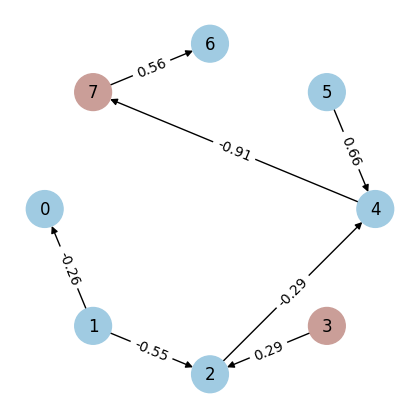

In [312]:
plot_dag(dag, colors=colors)

In [283]:
xai_model = ExplainerPFN(model_path=model_path, random_state=random_state, device=device)
explanations = get_all_explanations(xai_model, df)

  0%|          | 0/6 [00:00<?, ?it/s]

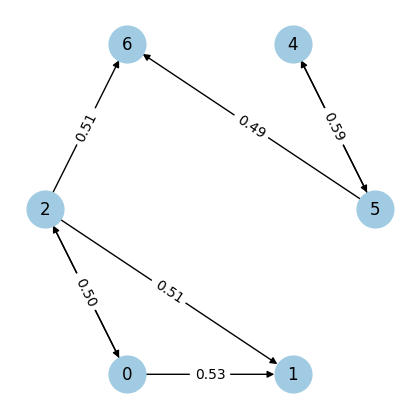

In [315]:
# Plot explanation graph
G_exp = make_dag_from_explanations(explanations, threshold=75)
plot_dag(G_exp)

In [ ]:
nx.graph_edit_distance(
    dag.to_undirected(), 
    make_dag_from_explanations(explanations, threshold=75).to_undirected()
)

5.0

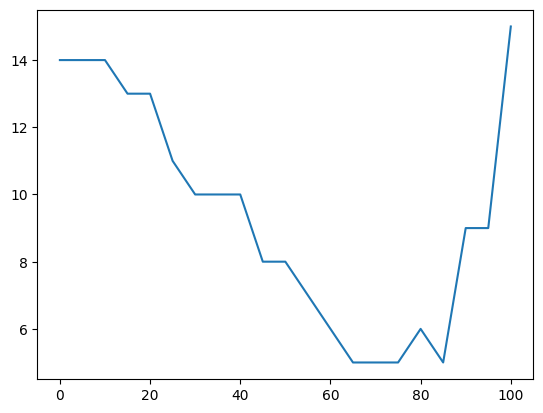

In [317]:
thresholds = list(range(0, 101, 5))
edit_distances = [
    nx.graph_edit_distance(
        dag.to_undirected(), 
        make_dag_from_explanations(explanations, threshold=t).to_undirected()
    )
    for t in thresholds
]
plt.plot(thresholds, edit_distances)

In [ ]:
# Generate several DAGs and get explanation graphs
xai_model = ExplainerPFN(model_path=model_path, random_state=random_state, device=device)
dags = []
dfs = []
explanations = []
for _ in tqdm(range(50)):
    params = generator._sample_params()
    df, dag = generator._dataset(**params, activations=[identity])
    df.drop(columns=df.columns[-1], inplace=True)  # Drop target column
    df.columns = df.columns.map(lambda x: x.split("_")[1])
    df = df.T.sort_index().T
    dfs.append(df)
    dags.append(dag)
    explanations.append(get_all_explanations(xai_model, df))

with open("synthetic_dags_explanations.pkl", "wb") as f:
    pickle.dump((dags, dfs, explanations), f)

In [ ]:
# dags, dfs, explanations = pickle.load(open("synthetic_dags_explanations.pkl", "rb"))

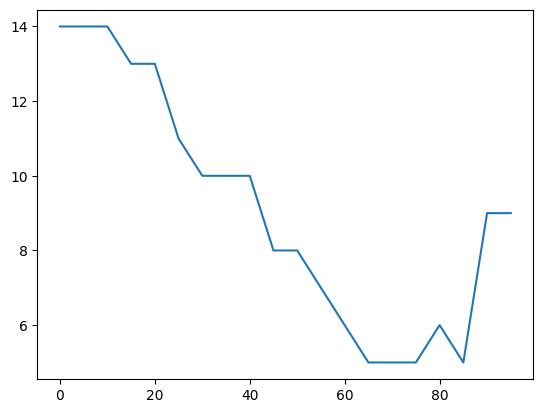

In [ ]:
thresholds = np.arange(0, 100, 5)
all_edit_distances = []
for dag, df, explanations in tqdm(zip(dags, dfs, explanations)):
    edit_distances = [
        nx.graph_edit_distance(
            dag.to_undirected(), 
            make_dag_from_explanations(explanations, threshold=t).to_undirected()
        )
        for t in thresholds
    ]
    all_edit_distances.append(edit_distances)


# Case Study: ACS Income

In [ ]:
# Tasks:
# 1. Recover causal structure
# 2. Help determine which ML model are more appropriate for a given dataset, based on how well they align with Shapley value expectations
# 3. Are faithful to regular feature importance measures
# 4. Compare different observations explanations
